# Comparação dos modelos base

Comparação das versões baseline das três arquiteturas com a configuração inicial:
- Normalização: `preprocess_input` específico de cada arquitetura
- Data augmentation: ativado
- Balanceamento de classes: desativado
- Learning rate: 0.001
- Threshold de decisão: 0.5

O objetivo é estabelecer uma linha de base (*baseline*) para as comparações subsequentes.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [ ]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações (gráficos e tabela csv) serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão salvas no Google Drive

In [ ]:
experiment_names = ["resnet-baseline", "densenet-baseline", "efficientnet-baseline"]
COMPARISON_PATH = "comparisons/00-base-model"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [ ]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [ ]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615


- O modelo resnet-baseline se demonstrou o com o melhor desempenho, com os maiores valores médios de acurácia, precisão, recall, score F1 e especificidade. Porém também se mostrou o modelo mais instável, com os maiores valores de desvio padrão dentre todos os experimentos.
- O modelo densenet-baseline se mostrou o menos performático, com todos os valores médios inferiores ao dos demais modelos. Contudo também se mostrou o modelo mais estável, com os menores desvios padrão em todas as métricas.
- O modelo efficientnet-baseline se mostrou o mais equilibrado entre os valores de média e desvio padrão, com valores intermediários entre os modelos anteriores. Algo que deve ser notado,  é que este modelo foi o que apresentou a maior AUC-ROC média, com desvio padrão razoavelmente baixo.

## Visualização dos gráficos de treino/validação

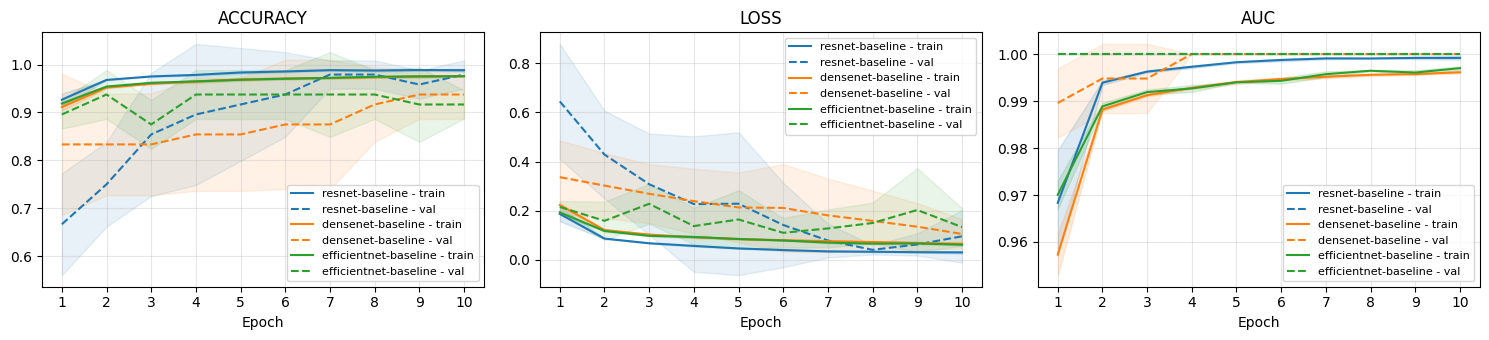

In [ ]:
from src.analyses import plot_training_history
import matplotlib.pyplot as plt

fig = plot_training_history(experiments)

plt.show()

- Todos os modelos apresentaram o comportamento esperado com a queda da curva de loss e aumento das curvas de acurácia e AUC-ROC.
- Como observado durante a fase exploratória, o tamanho reduzido do conjunto de validação (N=16) provova três comportamentos que podem ser facilmente visulizaos nos gráficos:
    - Alto desvio padrão das métricas durante a fase de validação
    - Saltos gráficos abruptos na curva de acurácia
    - Colapso da AUC-ROC durante a validação (auc=1), que não será usada nas próximas comparações do histórico de treino/validação

## Visualização das curvas ROC dos experimentos

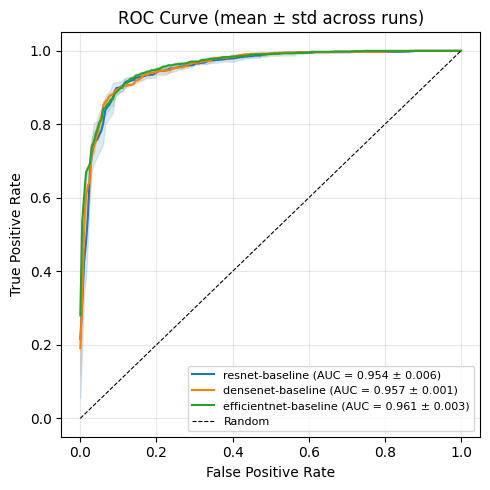

In [ ]:
from src.analyses import plot_roc_curves

fig = plot_roc_curves(experiments)

plt.show()

A análise gráfica mostra que as curvas ROC dos três experimentos estão notavelmente próximas, como sugerido pela análise das AUC-ROC anteriormente propunha.

## Conclusão

As três arquiteturas apresentaram desempenho similar no baseline, com AUC-ROC entre 0.954 e 0.961 e alta instabilidade na especificidade.
Dado o desempenho equivalente, todas as três arquiteturas foram mantidas para as fases seguintes da análise experimental.

## Salvamento da comparação completa

A comparação completa (tabela das métricas e comparações gráficas) é salva no Google Drive

In [ ]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  show_plot=False,
  save_dir=SAVE_DIR
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/00-base-model


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
)